<a href="https://colab.research.google.com/github/Tarakk/CML7211_ML4Chem/blob/main/Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install rdkit

In [32]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

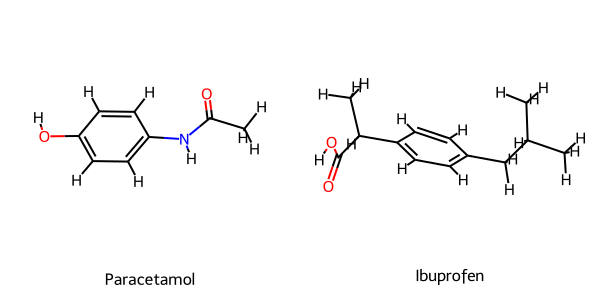

In [20]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

mol1_smiles = 'CC(=O)Nc1ccc(cc1)O' # paracetamol
mol2_smiles = 'CC(C)Cc1ccc(C(C)C(=O)O)cc1' # ibuprofen

mols = [Chem.MolFromSmiles(mol1_smiles), Chem.MolFromSmiles(mol2_smiles)]
legends = ["Paracetamol", "Ibuprofen"]

for i, mol in enumerate(mols):
    # add Hs
    mols[i] = Chem.AddHs(mol)

    # generate 3D using ETKDG algorithm
    AllChem.EmbedMolecule(mols[i], AllChem.ETKDG())

    # clean up geometry
    AllChem.MMFFOptimizeMolecule(mols[i])

# Draw the 3D-conformed molecules
Draw.MolsToGridImage(mols,
                    molsPerRow=2,
                    subImgSize=(300, 300),
                    legends=legends)

In [33]:
!pip install py3Dmol

In [22]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

def prepare_3d(mol):
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.UFFOptimizeMolecule(mol)
    return mol

def draw_3d(mols, names):
    assert len(mols) == len(names), "mols and names must have same length"

    view = py3Dmol.view(width=800, height=400, linked=True,
                        viewergrid=(1, len(mols)))

    for i in range(len(mols)):
        mol = mols[i]
        name = names[i]

        mb = Chem.MolToMolBlock(mol)

        view.addModel(mb, 'mol', viewer=(0, i))
        view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}}, viewer=(0, i))
        view.addLabel(name, {'fontSize': 14}, viewer=(0, i))
        view.zoomTo(viewer=(0, i))

    return view.show()


mol1 = Chem.MolFromSmiles("CC(=O)Nc1ccc(cc1)O")  # Paracetamol
mol2 = Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O")  # Ibuprofen

# 3D mols
mol1 = prepare_3d(mol1)
mol2 = prepare_3d(mol2)

# visualize
mols = [mol1, mol2]
names = ["Paracetamol", "Ibuprofen"]

draw_3d(mols, names)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [23]:
# Take Benzene for example

mol = Chem.MolFromSmiles('c1ccccc1')
#mol = Chem.AddHs(mol)
#AllChem.EmbedMolecule(mol)

n_atoms = mol.GetNumAtoms()
print(f'N of atoms: {n_atoms}')

#Get total number of bonds
n_bonds = mol.GetNumBonds()
print(f'N of bonds: {n_bonds}')

#create a list containing the atoms of the molecule
atoms = list(mol.GetAtoms())

#print the atomic number for each atom in the molecule
print("Atoms")
for atom in atoms:
    print(atom.GetSymbol(),atom.GetAtomicNum(),atom.GetHybridization(),atom.GetIsAromatic())

#create a list containing the bonds in the molecule
bonds = list(mol.GetBonds())

#print only the first three bonds in the list
print("Bonds")
for bond in bonds[0:10]:
    print(bond.GetBeginAtomIdx(),bond.GetEndAtomIdx(),bond.GetBondType())

N of atoms: 6
N of bonds: 6
Atoms
C 6 SP2 True
C 6 SP2 True
C 6 SP2 True
C 6 SP2 True
C 6 SP2 True
C 6 SP2 True
Bonds
0 1 AROMATIC
1 2 AROMATIC
2 3 AROMATIC
3 4 AROMATIC
4 5 AROMATIC
5 0 AROMATIC


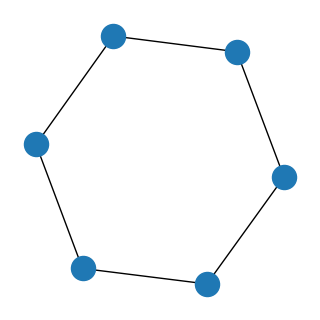

Scaled Adjacency Matrix:
[[0.  1.5 0.  0.  0.  1.5]
 [1.5 0.  1.5 0.  0.  0. ]
 [0.  1.5 0.  1.5 0.  0. ]
 [0.  0.  1.5 0.  1.5 0. ]
 [0.  0.  0.  1.5 0.  1.5]
 [1.5 0.  0.  0.  1.5 0. ]]


In [28]:
import networkx as nx
import matplotlib.pyplot as plt

mol = Chem.MolFromSmiles('c1ccccc1')

adj_matrix = Chem.GetAdjacencyMatrix(mol, useBO=True)

# Convert adjacency matrix to NetworkX graph
G = nx.from_numpy_array(adj_matrix)

# Add atom labels as node attributes
for atom in mol.GetAtoms():
    G.nodes[atom.GetIdx()]['element'] = atom.GetSymbol()

#nx.draw(G)
plt.figure(figsize=(3, 3))
nx.draw(G)
plt.show()


print("Scaled Adjacency Matrix:")
print(adj_matrix)

In [29]:
import numpy as np
eigenvalues, eigenfunctions = np.linalg.eigh(adj_matrix)

print("EIGENVALUES (Energy Levels):")
for i, val in enumerate(eigenvalues):
    print(f" λ_{i}: {val:>6.3f}")

print("\nEIGENFUNCTIONS (Coefficients):")
df_vecs = pd.DataFrame(
    eigenfunctions,
    columns=[f"v_{i}" for i in range(len(eigenvalues))],
    index=[atom.GetSymbol() for atom in mol.GetAtoms()]
)
print(df_vecs.round(3))

EIGENVALUES (Energy Levels):
 λ_0: -3.000
 λ_1: -1.500
 λ_2: -1.500
 λ_3:  1.500
 λ_4:  1.500
 λ_5:  3.000

EIGENFUNCTIONS (Coefficients):
     v_0    v_1    v_2    v_3  v_4    v_5
C -0.408 -0.577  0.001  0.577 -0.0 -0.408
C  0.408  0.288 -0.500  0.289 -0.5 -0.408
C -0.408  0.289  0.500 -0.289 -0.5 -0.408
C  0.408 -0.577  0.001 -0.577 -0.0 -0.408
C -0.408  0.288 -0.500 -0.289  0.5 -0.408
C  0.408  0.289  0.500  0.289  0.5 -0.408


In [30]:
BOND_FEATURES = {
    'bond_type' : [
        'SINGLE',
        'DOUBLE',
        'TRIPLE',
        'AROMATIC',
        'misc'
    ],
    'stereo': [
        'STEREONONE',
        'STEREOZ',
        'STEREOE',
        'STEREOCIS',
        'STEREOTRANS',
        'STEREOANY',
    ],
    'conjugated': [False, True],
}

def get_bond_fv(bond):
    """
    Converts rdkit bond object to feature list of indices
    :param bond: rdkit bond object
    :return: list
    """
    bond_fv = [
        BOND_FEATURES['bond_type'].index(str(bond.GetBondType())),
        BOND_FEATURES['stereo'].index(str(bond.GetStereo())),
        BOND_FEATURES['conjugated'].index(bond.GetIsConjugated()),
    ]
    return bond_fv

bond_fvs = [get_bond_fv(bond) for bond in mol.GetBonds()]
bond_fvs = np.array(bond_fvs)
print(bond_fvs)

[[3 0 1]
 [3 0 1]
 [3 0 1]
 [3 0 1]
 [3 0 1]
 [3 0 1]]


In [27]:
edge_index0, edge_index1 = [], []

for bond in mol.GetBonds():
    i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    edge_index0 += [i, j]
    edge_index1 += [j, i]

edge_index = [edge_index0, edge_index1]
edge_index

[[0, 1, 1, 2], [1, 0, 2, 1]]